In [ ]:
import cmocean
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import warnings
from pathlib import Path

import pycompo.core.composite as pccompo
import pycompo.core.utils as pcutil
import pycompo.core.plot as pcplot
import pycompo.core.sigtest as pcsig

import hfplot.figure.figure as hffig

warnings.filterwarnings(action='ignore')

# read in configuration file
idf = 'ngc5004_opv4_w0'
config_path = '/home/m/m300738/libs/pycompo/config'
config_file = f"{config_path}/settings_{idf}.yaml"
config = pcutil.read_yaml_config(config_file)
ana_times = pcutil.create_analysis_times(config)

### Read in composites

In [2]:
# read in composite and adjust units
inpath = Path(f"{config['data']['outpath']}/{idf}/")
infile_compo = Path(f"{idf}_composite_rainbelt.nc")
rb_compo = xr.open_dataset(str(inpath/infile_compo))

# read in p-values and calculate field significance
infile_pvalue = Path(f"{idf}_pvalue_rainbelt.nc")
rb_pvalue = xr.open_dataset(str(inpath/infile_pvalue))
rb_sigmask = pcsig.get_field_significance(rb_pvalue, alpha_FDR=0.1)

# correct composites by population means
rb_popmeans = []
ipath_popms = Path(f"{config['data']['outpath']}/{idf}/popmeans/")

for start_time, end_time in zip(ana_times, ana_times[1:]):
    fdate_str = pcutil.create_ftime_str(start_time, end_time)
    ifile = Path(f"{idf}_popmeans_rainbelt_{fdate_str}.nc")
    rb_popmeans.append(
        xr.open_dataset(ipath_popms/ifile).mean(dim='time').compute()
        )
rb_popmeans = xr.concat(rb_popmeans, dim='time').mean(dim="time")

rb_compo_corrected = rb_compo - rb_popmeans
rb_compo_corrected = pccompo.adjust_units(
    rb_compo_corrected, rb_compo_corrected.data_vars,
    )

### Plotting

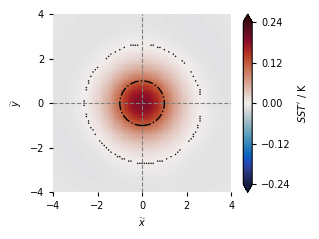

In [4]:
var = 'ts_ano_detect'
crange = [-0.24, 0.24]
clabel = "$SST\,\mathrm{'}$ / K"

# Plotting
fig, axes = hffig.init_fig(style=('ams', 'one_column'), asprat=(3.2, 2.4))

pl = axes[0, 0].pcolormesh(
    rb_compo_corrected[var]['En_rota2_featcen_x'],
    rb_compo_corrected[var]['En_rota2_featcen_y'],
    rb_compo_corrected[var].transpose(),
    vmin=crange[0], vmax=crange[1], cmap=cmocean.cm.balance, 
)
pcplot.plot_sigmask(axes[0, 0], rb_sigmask[var])

pcplot.plot_feature_grid(
    axes[0, 0],
    rb_compo_corrected['En_rota2_featcen_x'], 
    rb_compo_corrected['En_rota2_featcen_y'],
    )
pcplot.plot_feature_circle(axes[0, 0], (0, 0), 1, lw=1)
axes[0, 0].set_aspect('equal')
for spine in axes[0, 0].spines.values(): spine.set_visible(False)

plt.colorbar(
    pl, orientation='vertical', label=clabel, extend='both',
    ticks=np.linspace(crange[0], crange[1], 5)
    )

hffig.set_limit(axes, [-4, 4], [-4, 4])
hffig.set_ticks(axes, [-4, -2, 0, 2, 4], [-4, -2, 0, 2, 4])
hffig.set_label(axes, '$\\widetilde{x}$', '$\\widetilde{y}$')

# Save plot
plt.tight_layout()
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figure01.png')
plt.savefig(str(outpath/outfile), dpi=600, bbox_inches='tight')
plt.show()